# Decision Tree Regressor | Ames Housing

Predict house sale prices in Ames, Iowa .

Linear Regression draws a straight line through data. Logistic Regression draws a straight boundary between classes. Both fundamentally assume linear relationships. A Decision Tree makes no such assumption -- it learns axis-aligned splits that can capture non-linear patterns, interactions between features, and step changes in the target.

The tradeoff: trees are more flexible but far more prone to overfitting. Understanding and controlling that overfitting is the central lesson of this notebook.

**Direct comparison with Linear Regression:**
We use identical preprocessing to linear regression so the final RMSE scores are directly comparable. By the end you will see exactly where a Decision Tree beats Linear Regression and where it does not.

**What this notebook covers:**
1. How a Decision Tree actually makes decisions (the math)
2. Preprocessing pipeline identical to M1
3. Training an unpruned tree and observing overfitting
4. Controlling overfitting through hyperparameters
5. Visualizing the tree and reading its decisions
6. Feature importance
7. GridSearchCV to find the optimal tree
8. Direct comparison with M1 Linear Regression scores


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 1. Load Data

In [4]:
# UPDATE THIS PATH to where your train.csv is located
train = pd.read_csv('../../Datasets/HousePrice/train.csv')

print(f"Shape: {train.shape}")
print(f"Target -- SalePrice: min=${train.SalePrice.min():,}  max=${train.SalePrice.max():,}  mean=${train.SalePrice.mean():,.0f}")
print()
train.head(3)
print(train.isnull().sum())

Shape: (1460, 81)
Target -- SalePrice: min=$34,900  max=$755,000  mean=$180,921

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


## 2. How a Decision Tree Makes Decisions

**The core idea:** repeatedly split the data into two groups by asking a yes/no question about one feature, choosing the split that reduces prediction error the most.

**At each node, the algorithm:**
1. Considers every feature and every possible split value
2. For each candidate split, computes the reduction in Mean Squared Error
3. Chooses the split that reduces MSE the most (this is called the impurity criterion)
4. Repeats recursively on each resulting group until a stopping condition is met

**At each leaf node (terminal node):**
The prediction is simply the mean of all training samples that reached that leaf.

**Why this captures non-linearity:**
A tree with depth 3 can produce 8 different predictions for 8 different regions of the feature space. A linear model always produces a single straight-line prediction. The tree partitions space into rectangles; the linear model draws one hyperplane.

**The fundamental problem:**
A fully grown tree memorizes the training data perfectly -- every leaf contains exactly one sample and predicts it with zero error. This is extreme overfitting. Controlling tree depth is the central challenge.


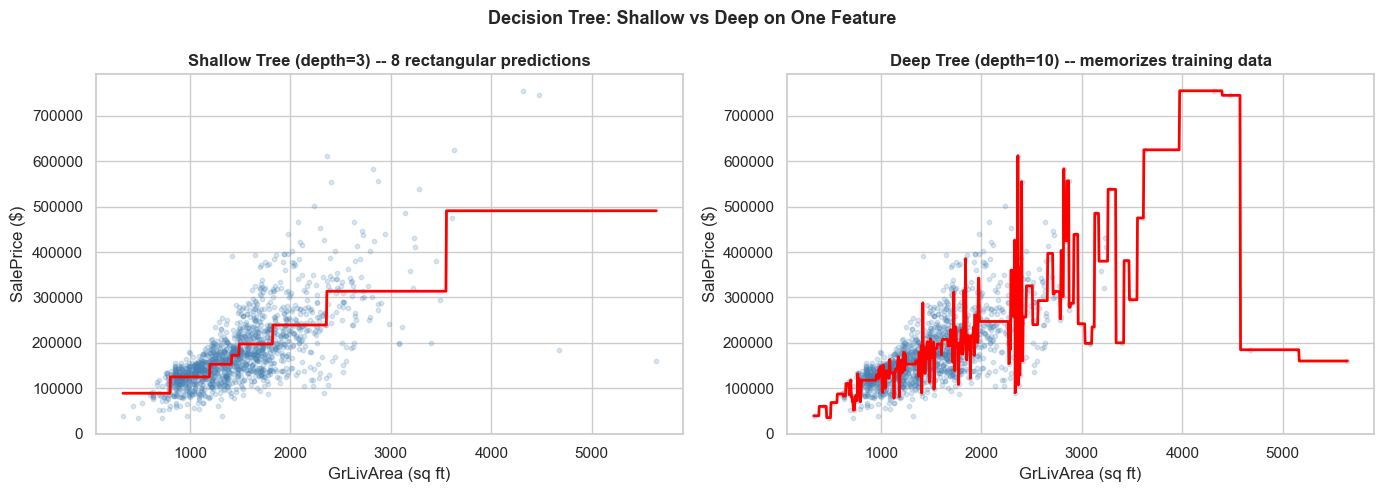

The step-function shape is the tree's prediction.
Shallow: smooth steps, generalizes well.
Deep: jagged, follows every data point including noise -- overfitting.


In [5]:
# Demonstrate the core concept on a single feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use GrLivArea (above-ground living area) vs SalePrice
x = train['GrLivArea'].values.reshape(-1, 1)
y = train['SalePrice'].values

# Shallow tree (depth 3) -- makes 8 rectangular predictions
tree_shallow = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_shallow.fit(x, y)

# Deep tree (depth 10) -- overfits
tree_deep = DecisionTreeRegressor(max_depth=10, random_state=42)
tree_deep.fit(x, y)

x_plot = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)

for ax, tree, title in zip(axes,
    [tree_shallow, tree_deep],
    ['Shallow Tree (depth=3) -- 8 rectangular predictions',
     'Deep Tree (depth=10) -- memorizes training data']):
    ax.scatter(x, y, alpha=0.2, s=10, color='steelblue')
    ax.plot(x_plot, tree.predict(x_plot), color='red', linewidth=2)
    ax.set_xlabel('GrLivArea (sq ft)')
    ax.set_ylabel('SalePrice ($)')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Decision Tree: Shallow vs Deep on One Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("The step-function shape is the tree's prediction.")
print("Shallow: smooth steps, generalizes well.")
print("Deep: jagged, follows every data point including noise -- overfitting.")

## 3. Preprocessing

Identical pipeline to M1 so scores are directly comparable at the end.

In [6]:
def handle_missing(df):
    df = df.copy()

    # NA means 'no feature' for these columns -- fill with 'None' or 0
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'MasVnrType']
    zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
                 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
                 'BsmtHalfBath', 'MasVnrArea']

    for col in none_cols:
        if col in df.columns: df[col] = df[col].fillna('None')
    for col in zero_cols:
        if col in df.columns: df[col] = df[col].fillna(0)

    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median()))

    for col in ['Electrical', 'MSZoning', 'Utilities', 'Functional',
                'Exterior1st', 'Exterior2nd', 'KitchenQual', 'SaleType']:
        if col in df.columns: df[col] = df[col].fillna(df[col].mode()[0])

    return df

def engineer_features(df):
    df = df.copy()
    df['TotalSF']        = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBathrooms'] = df['FullBath'] + df['BsmtFullBath'] + 0.5*df['HalfBath'] + 0.5*df['BsmtHalfBath']
    df['TotalPorchSF']   = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
    df['HouseAge']       = df['YrSold'] - df['YearBuilt']
    df['RemodAge']       = df['YrSold'] - df['YearRemodAdd']
    df['WasRemodeled']   = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['IsNew']          = (df['YrSold'] == df['YearBuilt']).astype(int)
    df['QualCond']       = df['OverallQual'] * df['OverallCond']
    df['HasPool']        = (df['PoolArea'] > 0).astype(int)
    df['HasGarage']      = (df['GarageArea'] > 0).astype(int)
    df['HasBasement']    = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace']   = (df['Fireplaces'] > 0).astype(int)
    return df

train = handle_missing(train)
train = engineer_features(train)
print("Preprocessing done")

Preprocessing done


In [7]:
# Ordinal encoding for quality columns
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
bsmt_exp = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
bsmt_fin = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
func_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
gar_fin  = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
paved    = {'Y': 2, 'P': 1, 'N': 0}

ordinal_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

for col in ordinal_cols:
    train[col] = train[col].map(qual_map).fillna(0)

train['BsmtExposure']  = train['BsmtExposure'].map(bsmt_exp).fillna(0)
train['BsmtFinType1']  = train['BsmtFinType1'].map(bsmt_fin).fillna(0)
train['BsmtFinType2']  = train['BsmtFinType2'].map(bsmt_fin).fillna(0)
train['Functional']    = train['Functional'].map(func_map).fillna(7)
train['GarageFinish']  = train['GarageFinish'].map(gar_fin).fillna(0)
train['PavedDrive']    = train['PavedDrive'].map(paved).fillna(0)
train['LandSlope']     = train['LandSlope'].map({'Gtl': 0, 'Mod': 1, 'Sev': 2}).fillna(0)
train['CentralAir']    = train['CentralAir'].map({'Y': 1, 'N': 0})

# One-hot encode remaining categoricals
nominal_cols = ['MSZoning','Street','Alley','LotShape','LandContour','Utilities',
                'LotConfig','Neighborhood','Condition1','Condition2','BldgType',
                'HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd',
                'MasVnrType','Foundation','Heating','Electrical','GarageType',
                'Fence','MiscFeature','SaleType','SaleCondition']

train = pd.get_dummies(train, columns=nominal_cols, drop_first=True, dtype=int)

# Log-transform skewed numeric features
numeric_feats = train.select_dtypes(include=np.number).columns.drop(['Id', 'SalePrice'])
skewness = train[numeric_feats].apply(lambda x: skew(x.dropna()))
skewed   = skewness[abs(skewness) > 0.75].index
for feat in skewed:
    train[feat] = np.log1p(train[feat].clip(lower=0))

# Target
y = np.log1p(train['SalePrice'])
X = train.drop(columns=['Id', 'SalePrice']).fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Features: {X.shape[1]}")

X_train: (1168, 219)  X_test: (292, 219)
Features: 219


## 4. The Overfitting Problem -- Unpruned Tree

In [8]:
# Train a fully grown tree with no constraints
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train, y_train)

train_rmse = np.sqrt(mean_squared_error(y_train, tree_full.predict(X_train)))
test_rmse  = np.sqrt(mean_squared_error(y_test,  tree_full.predict(X_test)))

print("=== Unpruned Decision Tree ===")
print(f"Max depth reached:    {tree_full.get_depth()}")
print(f"Number of leaves:     {tree_full.get_n_leaves()}")
print(f"Train RMSE (log):     {train_rmse:.5f}")
print(f"Test RMSE (log):      {test_rmse:.5f}")
print(f"Gap (overfit signal): {test_rmse - train_rmse:.5f}")
print()
print("Train RMSE is near zero -- the tree has memorized the training data.")
print("Test RMSE is much higher -- it has not learned to generalize.")
print("This is textbook overfitting.")

=== Unpruned Decision Tree ===
Max depth reached:    21
Number of leaves:     1123
Train RMSE (log):     0.00000
Test RMSE (log):      0.20281
Gap (overfit signal): 0.20281

Train RMSE is near zero -- the tree has memorized the training data.
Test RMSE is much higher -- it has not learned to generalize.
This is textbook overfitting.


## 5. Controlling Overfitting -- Key Hyperparameters

Decision Trees have several hyperparameters that control complexity. Understanding each one is the core skill.

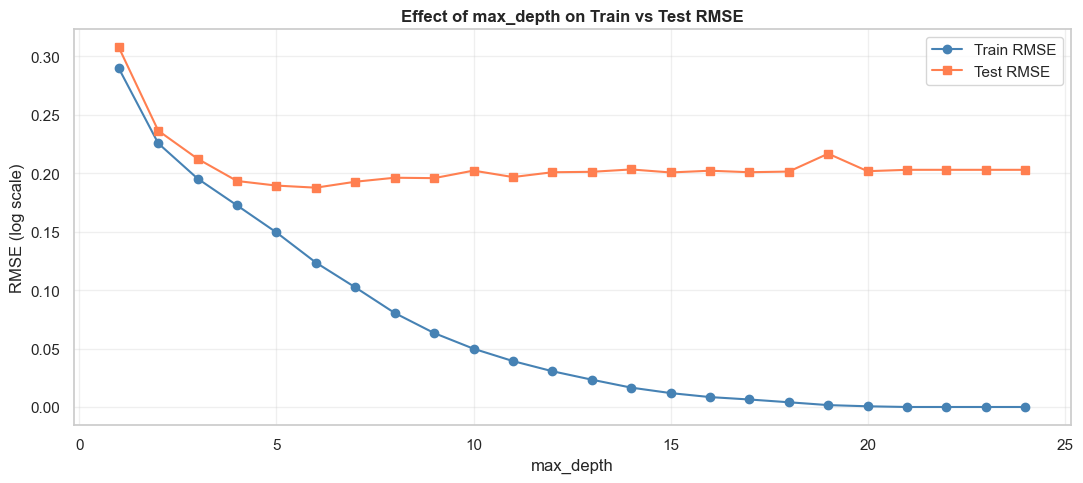

Best max_depth by test RMSE: 6

Reading the chart:
  Left side (small depth): both train and test RMSE high -- underfitting
  Right side (large depth): train RMSE near zero, test RMSE high -- overfitting
  Sweet spot: the depth where test RMSE is minimized


In [9]:
# Effect of max_depth -- the most important hyperparameter
depths = range(1, 25)
train_scores, test_scores = [], []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(np.sqrt(mean_squared_error(y_train, tree.predict(X_train))))
    test_scores.append(np.sqrt(mean_squared_error(y_test,  tree.predict(X_test))))

plt.figure(figsize=(11, 5))
plt.plot(depths, train_scores, 'o-', color='steelblue', label='Train RMSE')
plt.plot(depths, test_scores,  's-', color='coral',     label='Test RMSE')
plt.xlabel('max_depth')
plt.ylabel('RMSE (log scale)')
plt.title('Effect of max_depth on Train vs Test RMSE', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmin(test_scores)]
print(f"Best max_depth by test RMSE: {best_depth}")
print()
print("Reading the chart:")
print("  Left side (small depth): both train and test RMSE high -- underfitting")
print("  Right side (large depth): train RMSE near zero, test RMSE high -- overfitting")
print("  Sweet spot: the depth where test RMSE is minimized")

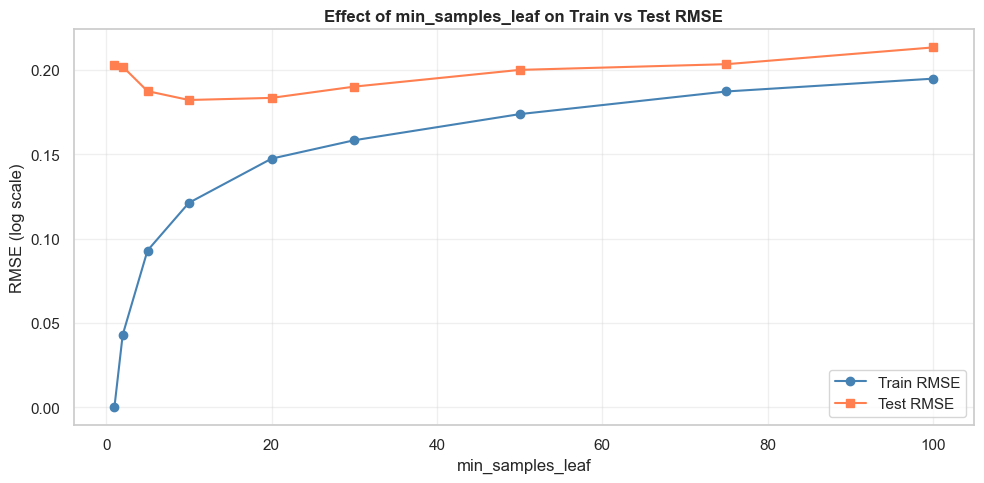

Best min_samples_leaf by test RMSE: 10

min_samples_leaf forces every leaf to represent at least N training samples.
Higher values: coarser tree, less overfitting, but may underfit.
Lower values: finer tree, more overfitting risk.


In [10]:
# Effect of min_samples_leaf -- minimum samples required at a leaf node
leaf_sizes = [1, 2, 5, 10, 20, 30, 50, 75, 100]
train_leaf, test_leaf = [], []

for ls in leaf_sizes:
    tree = DecisionTreeRegressor(min_samples_leaf=ls, random_state=42)
    tree.fit(X_train, y_train)
    train_leaf.append(np.sqrt(mean_squared_error(y_train, tree.predict(X_train))))
    test_leaf.append(np.sqrt(mean_squared_error(y_test,  tree.predict(X_test))))

plt.figure(figsize=(10, 5))
plt.plot(leaf_sizes, train_leaf, 'o-', color='steelblue', label='Train RMSE')
plt.plot(leaf_sizes, test_leaf,  's-', color='coral',     label='Test RMSE')
plt.xlabel('min_samples_leaf')
plt.ylabel('RMSE (log scale)')
plt.title('Effect of min_samples_leaf on Train vs Test RMSE', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_leaf = leaf_sizes[np.argmin(test_leaf)]
print(f"Best min_samples_leaf by test RMSE: {best_leaf}")
print()
print("min_samples_leaf forces every leaf to represent at least N training samples.")
print("Higher values: coarser tree, less overfitting, but may underfit.")
print("Lower values: finer tree, more overfitting risk.")

In [23]:
# Summary of all hyperparameters
params_explained = pd.DataFrame({
    'Hyperparameter': [
        'max_depth',
        'min_samples_split',
        'min_samples_leaf',
        'max_features',
        'max_leaf_nodes',
        'min_impurity_decrease'
    ],
    'What it controls': [
        'Maximum depth the tree can grow',
        'Minimum samples required to split a node',
        'Minimum samples required at a leaf',
        'Number of features to consider at each split',
        'Maximum number of leaf nodes',
        'Minimum MSE reduction required to make a split'
    ],
    'Effect of increasing': [
        'Increases overfitting (tree gets shallower)',
        'Less overfitting (fewer splits)',
        'Less overfitting (coarser leaves)',
        'Adds randomness, reduces overfitting',
        'Less overfitting (fewer partitions)',
        'Less overfitting (only meaningful splits made)'
    ]
})
print(params_explained.to_string(index=False))

       Hyperparameter                               What it controls                           Effect of increasing
            max_depth                Maximum depth the tree can grow    Increases overfitting (tree gets shallower)
    min_samples_split       Minimum samples required to split a node                Less overfitting (fewer splits)
     min_samples_leaf             Minimum samples required at a leaf              Less overfitting (coarser leaves)
         max_features   Number of features to consider at each split           Adds randomness, reduces overfitting
       max_leaf_nodes                   Maximum number of leaf nodes            Less overfitting (fewer partitions)
min_impurity_decrease Minimum MSE reduction required to make a split Less overfitting (only meaningful splits made)


## 6. GridSearchCV -- Find the Optimal Tree

In [12]:
param_grid = {
    'max_depth':        [3, 4, 5, 6, 7, 8, 10],
    'min_samples_leaf': [5, 10, 15, 20, 30],
    'min_samples_split':[2, 5, 10, 20],
    'max_features':     [None, 'sqrt', 0.5, 0.7],
}

total_combos = 7 * 5 * 4 * 4
print(f"Grid size: {total_combos} combinations x 5 folds = {total_combos * 5} fits")
print("Running GridSearchCV...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"Best parameters: {gs.best_params_}")
print(f"Best CV RMSE: {-gs.best_score_:.5f}")

Grid size: 560 combinations x 5 folds = 2800 fits
Running GridSearchCV...
Best parameters: {'max_depth': 7, 'max_features': 0.7, 'min_samples_leaf': 15, 'min_samples_split': 2}
Best CV RMSE: 0.17383


In [13]:
best_tree = gs.best_estimator_
y_pred = best_tree.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, best_tree.predict(X_train)))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred))
r2         = r2_score(y_test, y_pred)

print("=== Tuned Decision Tree Results ===")
print(f"Train RMSE (log): {train_rmse:.5f}")
print(f"Test RMSE (log):  {test_rmse:.5f}")
print(f"R-squared:        {r2:.5f}")
print(f"Gap:              {test_rmse - train_rmse:.5f}")
print()

# Dollar error
dollar_pred = np.expm1(y_pred)
dollar_true = np.expm1(y_test)
dollar_mae  = mean_absolute_error(dollar_true, dollar_pred)
print(f"MAE in dollars: ${dollar_mae:,.0f}  (average prediction error)")

=== Tuned Decision Tree Results ===
Train RMSE (log): 0.14363
Test RMSE (log):  0.18728
R-squared:        0.81205
Gap:              0.04365

MAE in dollars: $22,687  (average prediction error)


## 7. Visualizing the Tree

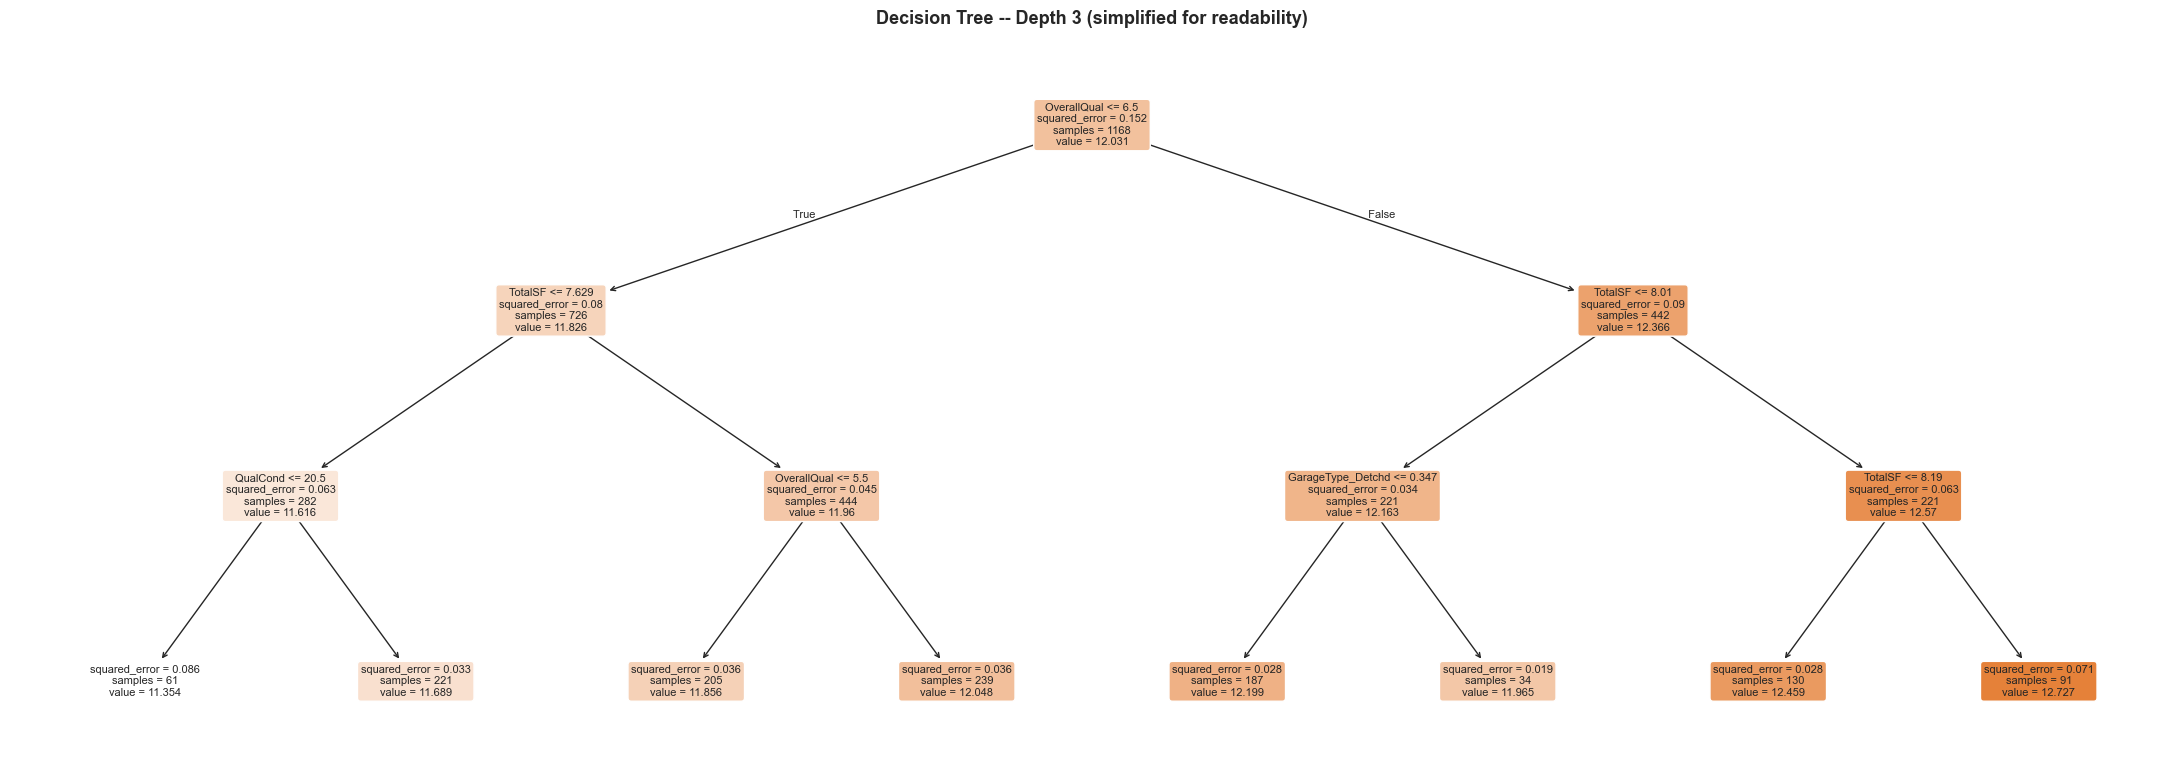

In [14]:
# Visualize a shallow version (depth 3) for readability
tree_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_viz.fit(X_train, y_train)

plt.figure(figsize=(22, 8))
plot_tree(
    tree_viz,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=True,
    precision=3
)
plt.title('Decision Tree -- Depth 3 (simplified for readability)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Print the tree as text -- easier to read the logic
tree_rules = export_text(tree_viz, feature_names=X_train.columns.tolist())
# Show first 60 lines only -- full tree would be very long
lines = tree_rules.split('\n')[:60]
print("Decision Tree Rules (first 60 lines):")
print('\n'.join(lines))
print("...")
print()
print("Reading the rules:")
print("  Each '|---' is one split condition")
print("  'value' at a leaf = the predicted log(SalePrice) for that group")
print("  'samples' = how many training observations reach that node")
print("  'squared_error' = MSE at that node (lower = purer node)")

Decision Tree Rules (first 60 lines):
|--- OverallQual <= 6.50
|   |--- TotalSF <= 7.63
|   |   |--- QualCond <= 20.50
|   |   |   |--- value: [11.35]
|   |   |--- QualCond >  20.50
|   |   |   |--- value: [11.69]
|   |--- TotalSF >  7.63
|   |   |--- OverallQual <= 5.50
|   |   |   |--- value: [11.86]
|   |   |--- OverallQual >  5.50
|   |   |   |--- value: [12.05]
|--- OverallQual >  6.50
|   |--- TotalSF <= 8.01
|   |   |--- GarageType_Detchd <= 0.35
|   |   |   |--- value: [12.20]
|   |   |--- GarageType_Detchd >  0.35
|   |   |   |--- value: [11.96]
|   |--- TotalSF >  8.01
|   |   |--- TotalSF <= 8.19
|   |   |   |--- value: [12.46]
|   |   |--- TotalSF >  8.19
|   |   |   |--- value: [12.73]

...

Reading the rules:
  Each '|---' is one split condition
  'value' at a leaf = the predicted log(SalePrice) for that group
  'samples' = how many training observations reach that node
  'squared_error' = MSE at that node (lower = purer node)


## 8. Feature Importance

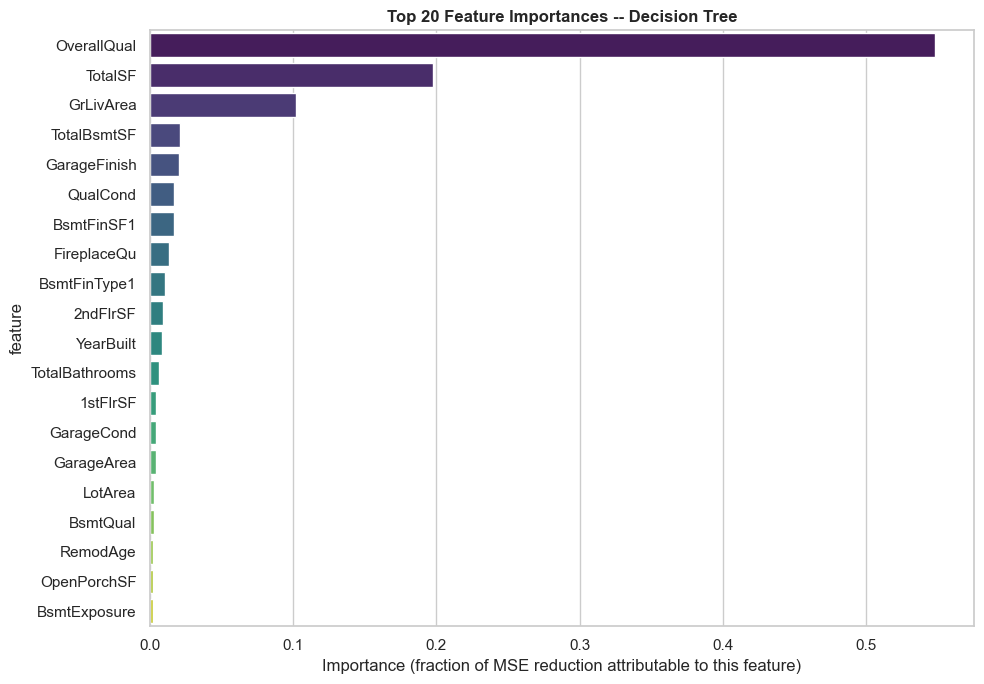

Top 10 features:
     feature  importance
 OverallQual    0.547698
     TotalSF    0.197269
   GrLivArea    0.102017
 TotalBsmtSF    0.021288
GarageFinish    0.020412
    QualCond    0.016885
  BsmtFinSF1    0.016774
 FireplaceQu    0.013680
BsmtFinType1    0.010235
    2ndFlrSF    0.008942

Feature importance in a Decision Tree = fraction of total MSE reduction
achieved by splits on that feature, weighted by the number of samples at each split.

Features with zero importance were never used for any split in the final tree.
Features with zero importance: 194 out of 219


In [16]:
importances = best_tree.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

# Top 20
top = feat_imp.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=top, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances -- Decision Tree', fontweight='bold')
plt.xlabel('Importance (fraction of MSE reduction attributable to this feature)')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(top.head(10).to_string(index=False))
print()
print("Feature importance in a Decision Tree = fraction of total MSE reduction")
print("achieved by splits on that feature, weighted by the number of samples at each split.")
print()
print("Features with zero importance were never used for any split in the final tree.")
print(f"Features with zero importance: {(importances == 0).sum()} out of {len(importances)}")

## 9. Actual vs Predicted and Residuals

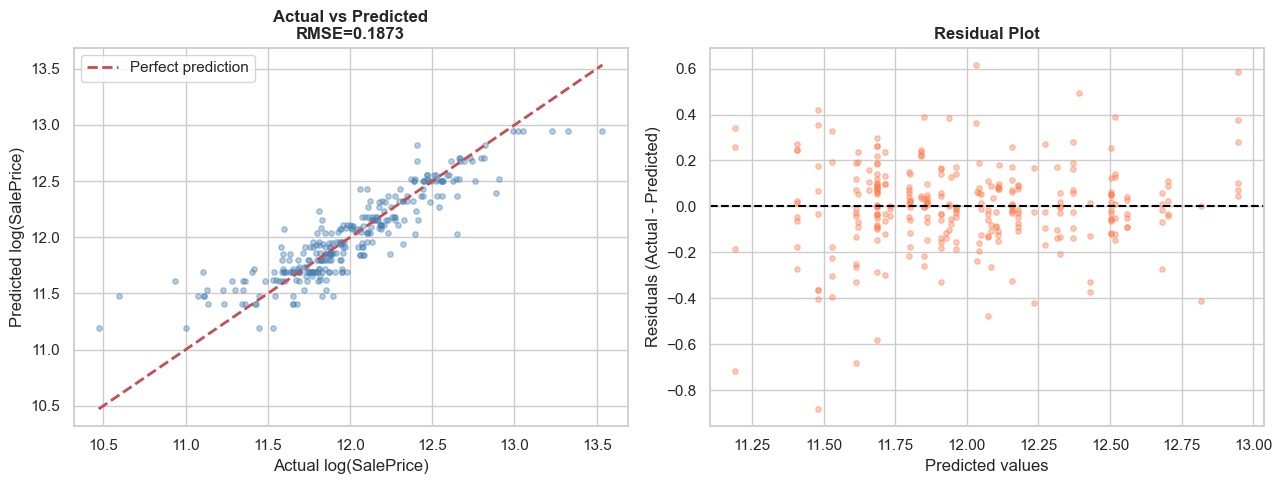

Residual mean: -0.00103  (should be near zero)
Residual std:  0.18760


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual log(SalePrice)')
axes[0].set_ylabel('Predicted log(SalePrice)')
axes[0].set_title(f'Actual vs Predicted\nRMSE={test_rmse:.4f}', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.5f}  (should be near zero)")
print(f"Residual std:  {residuals.std():.5f}")

## 10. Cross-Validation

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = -cross_val_score(
    best_tree, X, y, cv=kf,
    scoring='neg_root_mean_squared_error'
)

print("5-Fold Cross-Validation RMSE:")
for i, s in enumerate(cv_scores, 1):
    bar = '#' * int(s * 200)
    print(f"  Fold {i}: {s:.5f}  {bar}")
print()
print(f"  Mean RMSE: {cv_scores.mean():.5f}")
print(f"  Std Dev:   {cv_scores.std():.5f}")

5-Fold Cross-Validation RMSE:
  Fold 1: 0.18728  #####################################
  Fold 2: 0.16972  #################################
  Fold 3: 0.19835  #######################################
  Fold 4: 0.17530  ###################################
  Fold 5: 0.15886  ###############################

  Mean RMSE: 0.17790
  Std Dev:   0.01373


## 11. Decision Tree vs Linear Regression -- Head to Head

In [19]:
# Re-run Linear Regression (Ridge) with identical preprocessing
from sklearn.linear_model import RidgeCV

ridge = Pipeline([
    ('scaler', RobustScaler()),
    ('model', RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100, 200], cv=kf))
])

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

ridge_cv = -cross_val_score(ridge, X, y, cv=kf, scoring='neg_root_mean_squared_error')

# Decision Tree CV
dt_cv = -cross_val_score(best_tree, X, y, cv=kf, scoring='neg_root_mean_squared_error')

print("=" * 58)
print("  M1 vs M3 -- Direct Comparison (identical preprocessing)")
print("=" * 58)
print(f"{'Model':<30} {'Test RMSE':>10} {'CV RMSE':>10} {'CV Std':>8}")
print("-" * 58)
print(f"{'Ridge Regression (M1)':<30} {ridge_rmse:>10.5f} {ridge_cv.mean():>10.5f} {ridge_cv.std():>8.5f}")
print(f"{'Decision Tree (M3)':<30} {test_rmse:>10.5f} {dt_cv.mean():>10.5f} {dt_cv.std():>8.5f}")
print()

if dt_cv.mean() < ridge_cv.mean():
    diff = ridge_cv.mean() - dt_cv.mean()
    print(f"Decision Tree wins by {diff:.5f} RMSE")
else:
    diff = dt_cv.mean() - ridge_cv.mean()
    print(f"Ridge Regression wins by {diff:.5f} RMSE")

print()
print("Key observations:")
print("  Decision Trees are more flexible but require careful tuning.")
print("  Ridge Regression is more stable (lower CV std) on tabular data with many features.")
print("  On this dataset, both are reasonable baselines.")
print("  Random Forest (M4) will improve on both by combining many trees.")

  M1 vs M3 -- Direct Comparison (identical preprocessing)
Model                           Test RMSE    CV RMSE   CV Std
----------------------------------------------------------
Ridge Regression (M1)             0.12952    0.13069  0.02070
Decision Tree (M3)                0.18728    0.17790  0.01373

Ridge Regression wins by 0.04721 RMSE

Key observations:
  Decision Trees are more flexible but require careful tuning.
  Ridge Regression is more stable (lower CV std) on tabular data with many features.
  On this dataset, both are reasonable baselines.
  Random Forest (M4) will improve on both by combining many trees.


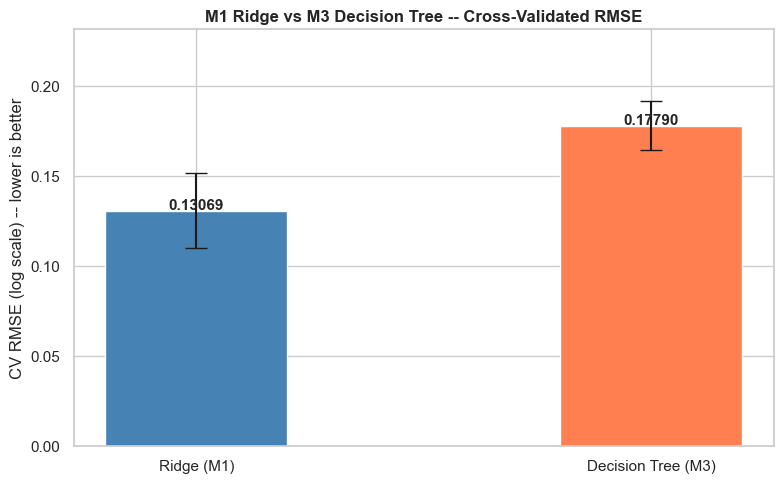

In [20]:
# Visual comparison
models  = ['Ridge (M1)', 'Decision Tree (M3)']
cv_means = [ridge_cv.mean(), dt_cv.mean()]
cv_stds  = [ridge_cv.std(),  dt_cv.std()]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'coral']
bars = ax.bar(models, cv_means, yerr=cv_stds, color=colors, capsize=8,
              edgecolor='white', width=0.4)
ax.set_ylabel('CV RMSE (log scale) -- lower is better')
ax.set_title('M1 Ridge vs M3 Decision Tree -- Cross-Validated RMSE', fontweight='bold')
for bar, mean in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{mean:.5f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(cv_means) * 1.3)
plt.tight_layout()
plt.show()

## Summary

**What Decision Trees do well:**
- No assumption of linearity -- can learn step-changes and thresholds
- No feature scaling required -- splits are based on rank, not magnitude
- Highly interpretable when shallow -- you can trace any prediction through the rules
- Naturally handles interactions between features through sequential splits
- Fast to train and predict

**What Decision Trees struggle with:**
- Extreme tendency to overfit -- a fully grown tree memorizes training data completely
- High variance -- a small change in the training data can produce a completely different tree
- Axis-aligned splits only -- diagonal boundaries require many splits to approximate
- On tabular data with many features, they are almost always outperformed by ensembles

**The key insight for this dataset:**
The tree's best features (OverallQual, TotalSF, Neighborhood, GrLivArea) align almost exactly with the Ridge Regression coefficients from M1. The data is telling us the same story through both models. The difference is in how they use that information -- Ridge weights features linearly, the tree partitions space into rectangular regions.
